# RadarGen Inference - TruckScenes

This notebook demonstrates how to use RadarGen for inference on the TruckScenes dataset.

In [ ]:
import sys
sys.path.append("..")

%load_ext autoreload
%autoreload 2

## Setup

Import the necessary modules and initialize the TruckScenes dataset.

In [ ]:
from truckscenes import TruckScenes

from radargen.datasets.truckscenes import TruckScenesAdapter
from radargen.inference import RadarGenInference
from notebooks.visualization.bev_visualizer import visualize_pcl_on_bev, visualize_bev_maps, visualize_camera_images

In [ ]:
# Initialize TruckScenes dataset
DATAROOT = '/path/to/man-truckscenes/'
trucksc = TruckScenes('v1.0-trainval', DATAROOT)

Loading truckscenes tables for version v1.0-trainval...
11 attribute,
18 calibrated_sensor,
27 category,
1200243 ego_motion_cabin,
1200183 ego_motion_chassis,
1201993 ego_pose,
43769 instance,
23902 sample,
819536 sample_annotation,
2586264 sample_data,
598 scene,
18 sensor,
4 visibility,
Done loading in 31.461 seconds.
Reverse indexing ...
Done reverse indexing in 9.2 seconds.


In [4]:
# Create the dataset adapter
adapter = TruckScenesAdapter(trucksc)

# Get scene tokens for validation split
scenes = list(adapter.iter_scenes('val'))
print(f"Found {len(scenes)} validation scenes")

Found 49 validation scenes


## Initialize RadarGen Model

The model can be initialized with or without an adapter. When using an adapter, you can directly pass sample data dictionaries.

In [ ]:
# Initialize RadarGen with the adapter for convenient data loading
model = RadarGenInference(
    config="../configs/RadarGen_600M_512px_TS_inference.yaml",
    adapter=adapter
)

## Run Inference

Select a scene and frame to process.

In [7]:
# Get samples for the first validation scene
scene_token, samples = scenes[10]
# samples already obtained from iter_scenes above
print(f"Scene has {len(samples)} frames")

Scene has 195 frames


In [8]:
# Get two consecutive frames for velocity estimation
frame_idx = 16  # Choose a frame
sample_data_t0 = samples[frame_idx]
sample_data_t1 = samples[frame_idx + 1]

Let's visualize the multi-view camera images that are used as input to RadarGen.

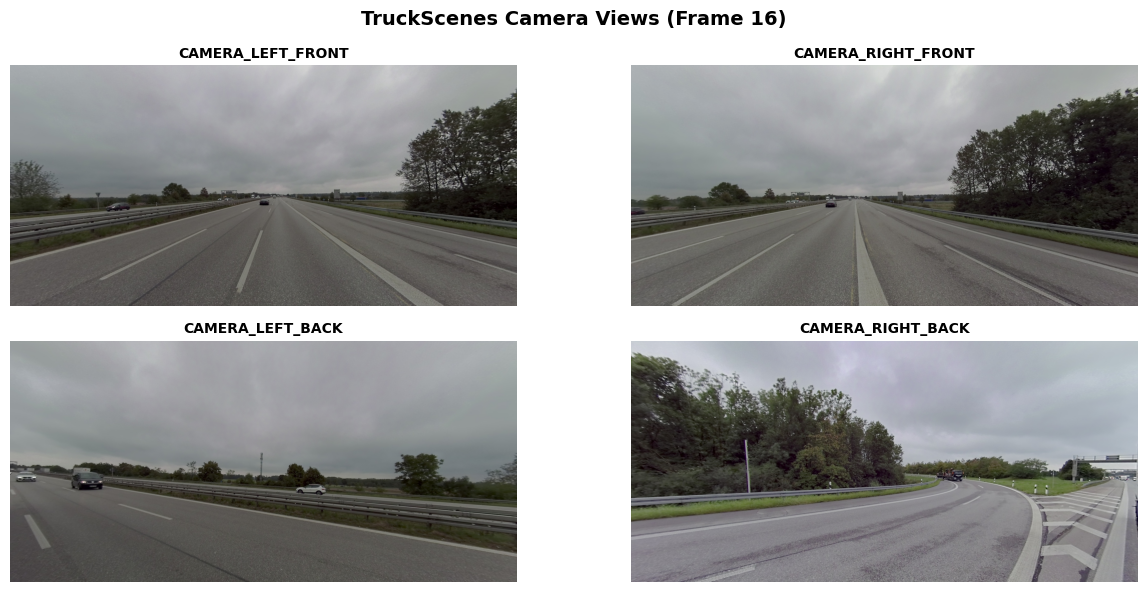

In [9]:
# Load camera images for the current frame

camera_images = adapter.load_camera_images(sample_data_t0)
camera_names = adapter.config.camera_views

# Visualize the camera images
camera_image_vis = [camera_images[1], camera_images[0], camera_images[3], camera_images[2]]
camera_names_vis = [camera_names[1], camera_names[0], camera_names[3], camera_names[2]]
visualize_camera_images(
    camera_image_vis,
    camera_names=camera_names_vis,
    title=f"TruckScenes Camera Views (Frame {frame_idx})",
    ncols=2  # 2 columns for 4 camera views
)


In [10]:
# Run inference using the adapter convenience method
radar_pcl = model.from_sample_data(
    sample_data_t0,
    sample_data_t1,
    num_inference_steps=20
)
print(f"Generated {len(radar_pcl)} radar points")
print(f"Point cloud shape: {radar_pcl.shape}  # [x, y, z, rcs, doppler]")

100%|██████████| 19/19 [00:00<00:00, 31.33it/s]


Generated 1840 radar points
Point cloud shape: (1840, 5)  # [x, y, z, rcs, doppler]


## Visualize Results

Visualize the generated radar point cloud on the BEV appearance map.

In [11]:
from radargen.datasets.base import build_inference_input

# Build inference input to get the BEV maps for visualization
input_t0 = build_inference_input(adapter, sample_data_t0)
input_t1 = build_inference_input(adapter, sample_data_t1)

# Compute per-camera time deltas from hardware timestamps
timestamps_t0 = adapter.get_camera_timestamps(sample_data_t0)
timestamps_t1 = adapter.get_camera_timestamps(sample_data_t1)
dts = [abs(ts1 - ts0) / 1e6 for ts0, ts1 in zip(timestamps_t0, timestamps_t1)]

# Generate BEV maps
bev_appearance_map, bev_segmentation_map, bev_velocity_map = model.mv_to_bev_maps(
    input_t0, input_t1, dts=dts
)

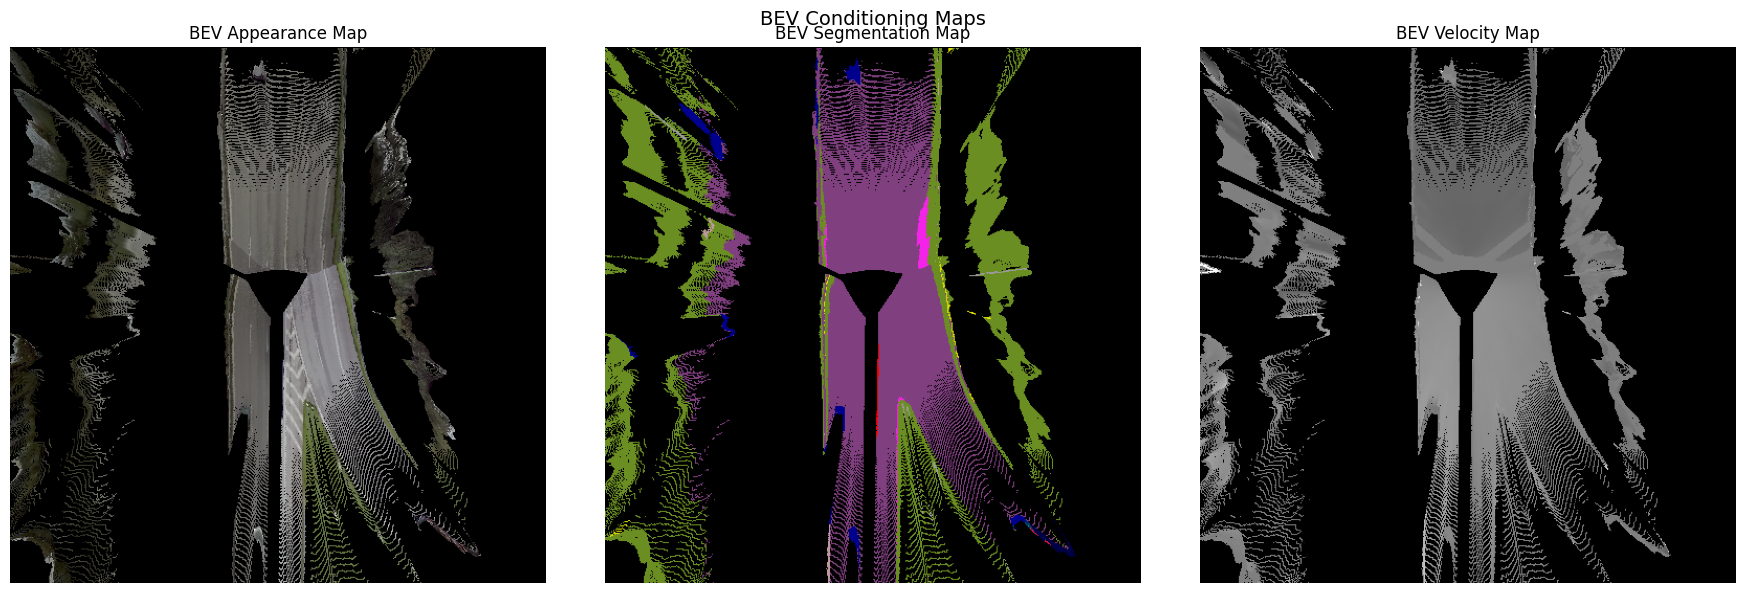

In [12]:
# Visualize BEV conditioning maps
visualize_bev_maps(
    bev_appearance_map,
    bev_segmentation_map,
    bev_velocity_map,
    title="BEV Conditioning Maps"
)

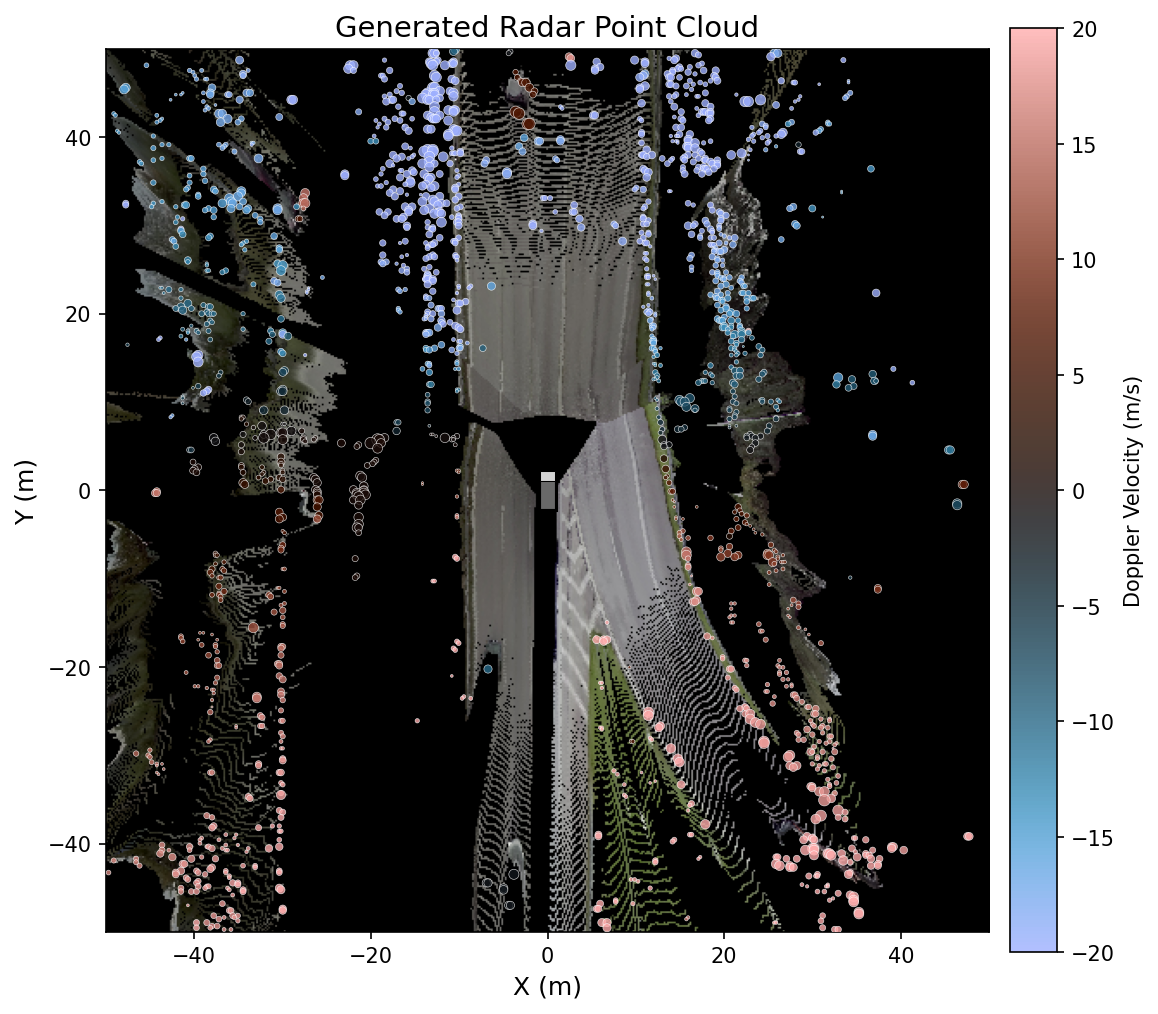

In [13]:
# Visualize radar point cloud on BEV
visualize_pcl_on_bev(
    radar_pcl,
    bev_appearance_map,
    normalization=adapter.normalization,
    title="Generated Radar Point Cloud"
)